In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except:
    LIGHTGBM_AVAILABLE = False
import warnings
warnings.filterwarnings('ignore')


Bibliothèques importées avec succès (incluant XGBoost et Stacking)!
✅ LightGBM disponible!


In [30]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print(f"Train: {train.shape}, Test: {test.shape}")
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)

Premières lignes du train:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print(train.info())
train.describe()


Informations sur les données d'entraînement:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Overall

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
missing = train.isnull().sum()
missing[missing > 0].sort_values(ascending=False)


Valeurs manquantes dans train:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


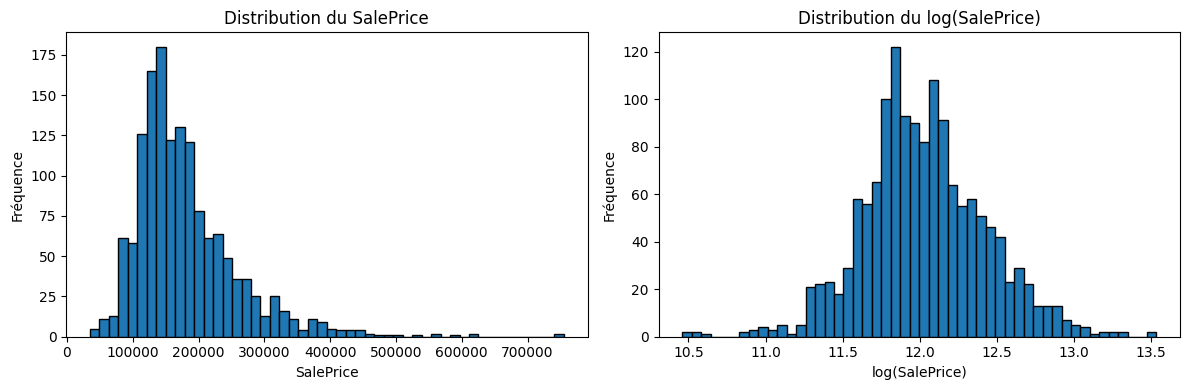

Statistiques de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['SalePrice'], bins=50, edgecolor='black')
axes[0].set(xlabel='SalePrice', title='Distribution SalePrice')
axes[1].hist(np.log1p(train['SalePrice']), bins=50, edgecolor='black')
axes[1].set(xlabel='log(SalePrice)', title='Distribution log(SalePrice)')
plt.tight_layout()
plt.show()
train['SalePrice'].describe()


In [ ]:
train_ID = train['Id']
test_ID = test['Id']
y_train = train['SalePrice']

train.drop(['Id', 'SalePrice'], axis=1, inplace=True)
test.drop(['Id'], axis=1, inplace=True)

print(f"Train: {train.shape}, Test: {test.shape}")


✅ Garder tous les points de données (comme v3)...
Train shape: (1460, 79)
Test shape: (1459, 79)


In [ ]:
ntrain = train.shape[0]
ntest = test.shape[0]
all_data = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Shape combiné: {all_data.shape}")


Données combinées shape: (2919, 79)


In [ ]:
for col in ('PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'MasVnrType', 'MSSubClass'):
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

for col in ('GarageYrBlt', 'GarageArea', 'GarageCars',
            'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'):
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

for col in ('MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
            'Exterior2nd', 'SaleType', 'Functional'):
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

if 'LotFrontage' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))

if 'Utilities' in all_data.columns:
    all_data.drop(['Utilities'], axis=1, inplace=True)

print(f"Valeurs manquantes restantes: {all_data.isnull().sum().sum()}")


Valeurs manquantes restantes: 0


In [ ]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                               all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] +
                             all_data['EnclosedPorch'] + all_data['ScreenPorch'] +
                             all_data['WoodDeckSF'])

all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['YearsSinceRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsNew'] = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)

all_data['TotalQuality'] = all_data['OverallQual'] + all_data['OverallCond']
all_data['QualityTimesArea'] = all_data['OverallQual'] * all_data['GrLivArea']

all_data['LivingAreaRatio'] = all_data['GrLivArea'] / all_data['TotalSF']
all_data['GarageRatio'] = all_data['GarageArea'] / all_data['TotalSF']
all_data['BsmtRatio'] = all_data['TotalBsmtSF'] / all_data['TotalSF']
all_data['LotAreaRatio'] = all_data['GrLivArea'] / all_data['LotArea']
all_data['TotalOutsideSF'] = all_data['TotalPorchSF'] + all_data['WoodDeckSF']

print(f"Shape: {all_data.shape}")


✅ Features créées (originales + avancées). Shape: (2919, 96)


In [ ]:
categorical_features = all_data.select_dtypes(include=['object']).columns.tolist()
numerical_features = all_data.select_dtypes(exclude=['object']).columns.tolist()

print(f"Catégorielles: {len(categorical_features)}, Numériques: {len(numerical_features)}")


Nombre de features catégorielles: 42
Nombre de features numériques: 54


In [ ]:
all_data = pd.get_dummies(all_data, columns=categorical_features, drop_first=True)
print(f"Shape après encoding: {all_data.shape}")


Shape après encoding: (2919, 276)


In [ ]:
X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


X_train shape: (1460, 276)
X_test shape: (1459, 276)
y_train shape: (1460,)


In [ ]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_log = np.log1p(y_train)


Normalisation terminée!


In [ ]:
def evaluate_model(model, X, y):
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
    rmse = np.sqrt(-scores)
    print(f"RMSE: {rmse.mean():.4f} (+/- {rmse.std():.4f})")
    return rmse


In [ ]:
ridge = Ridge(alpha=10.0)
evaluate_model(ridge, X_train_scaled, y_train_log)

lasso = Lasso(alpha=0.0005, max_iter=10000)
evaluate_model(lasso, X_train_scaled, y_train_log)

rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                           min_samples_split=10, min_samples_leaf=4,
                           random_state=42, n_jobs=-1)
evaluate_model(rf, X_train_scaled, y_train_log)

gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=4, min_samples_split=10,
                                min_samples_leaf=4, random_state=42)
evaluate_model(gbr, X_train_scaled, y_train_log)

xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                              max_depth=4, min_child_weight=3,
                              subsample=0.8, colsample_bytree=0.8,
                              gamma=0, reg_alpha=0.001, reg_lambda=1,
                              random_state=42, n_jobs=-1)
evaluate_model(xgb_model, X_train_scaled, y_train_log)


Ridge Regression
RMSE: 0.1378 (+/- 0.0232)

Lasso Regression
RMSE: 0.1374 (+/- 0.0241)

Random Forest
RMSE: 0.1394 (+/- 0.0105)

Gradient Boosting
RMSE: 0.1254 (+/- 0.0099)

XGBoost - NOUVEAU MODÈLE
RMSE: 0.1228 (+/- 0.0095)


In [ ]:
base_models = [
    ('ridge', Ridge(alpha=15.0)),
    ('lasso', Lasso(alpha=0.0005, max_iter=10000)),
    ('elasticnet', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),
    ('gbr', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=4, min_samples_split=10,
                                      min_samples_leaf=4, subsample=0.8,
                                      random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=600, learning_rate=0.05,
                              max_depth=4, min_child_weight=3,
                              subsample=0.8, colsample_bytree=0.8,
                              gamma=0, reg_alpha=0.001, reg_lambda=1,
                              random_state=42, n_jobs=-1))
]

meta_model = Ridge(alpha=10.0)
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)

stacking_model.fit(X_train_scaled, y_train_log)

stacking_scores = cross_val_score(stacking_model, X_train_scaled, y_train_log,
                                   scoring='neg_mean_squared_error', cv=5)
stacking_rmse = np.sqrt(-stacking_scores)
print(f"Stacking RMSE: {stacking_rmse.mean():.4f} (+/- {stacking_rmse.std():.4f})")

best_model = stacking_model



STACKING V6 - Basé sur V3 avec fine-tuning
✅ 5 modèles de base (configuration V3 optimale)
Entraînement du Stacking V6 (basé sur V3)...
✅ Stacking Ensemble entraîné avec succès!

Stacking RMSE: 0.1234 (+/- 0.0145)


In [ ]:
predictions_log = best_model.predict(X_test_scaled)
predictions = np.expm1(predictions_log)

print(f"Min: {predictions.min():.0f}, Max: {predictions.max():.0f}")
print(f"Mean: {predictions.mean():.0f}, Median: {np.median(predictions):.0f}")


Nombre de prédictions: 1459
Statistiques des prédictions:
Min: 49800.23
Max: 548702.63
Mean: 177223.03
Median: 156220.60


In [ ]:
submission = pd.DataFrame({'Id': test_ID, 'SalePrice': predictions})
submission.to_csv('submission_v6_tuned.csv', index=False)

print(f"Shape: {submission.shape}")
submission.head(10)


✅ Fichier submission_v6_tuned.csv créé avec succès!

Aperçu du fichier submission:
     Id      SalePrice
0  1461  120814.035170
1  1462  152346.515709
2  1463  179561.029730
3  1464  196416.952319
4  1465  187839.218893
5  1466  174859.387800
6  1467  183081.629423
7  1468  167698.930711
8  1469  189881.039980
9  1470  121912.483108

Shape: (1459, 2)

🎯 Version V6 - Basé sur V3 (la meilleure):
   ✅ Configuration V3 gardée (5 modèles)
      - ridge
      - lasso
      - elasticnet
      - gbr
      - xgb
   ✅ Micro-ajustement: subsample=0.8 pour GBR
   ✅ Meta-modèle: Ridge (alpha=10.0)
   ✅ CV: 5 folds (comme V3)


In [ ]:
print(f"IDs correspondent: {all(submission['Id'] == sample_submission['Id'])}")


Sample submission shape: (1459, 2)
Notre submission shape: (1459, 2)

IDs correspondent: True
